In [7]:
# Import the Python libraries
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List

In [8]:
class SimpleHopfieldNetwork:
    def __init__(self, num_neurons: int):
        self.num_neurons = num_neurons
        self.weights = np.zeros((num_neurons, num_neurons))

    def train(self, patterns: List[np.ndarray]):
        """
        Train using Hebbian learning rule.
        Patterns must be bipolar (-1, +1).

        Args
        -----
        - patterns: A list of 2D numpy arrays representing the patterns to store.

        Returns
        -------
        None
        """
        self.weights.fill(0)

        for pattern in patterns:
            x = pattern.ravel(order='C').astype(float)

            if x.size != self.num_neurons:
                raise ValueError("Pattern size does not match number of neurons.")

            # Hebbian outer product
            self.weights += np.outer(x, x)

        # Normalize once
        self.weights /= self.num_neurons

        # Remove self-connections
        np.fill_diagonal(self.weights, 0)

    def recall(self, 
               pattern: np.ndarray, 
               steps:int=5,
               synchronous: bool=True) -> np.ndarray:
        r"""Recall a pattern from the network. The input pattern can be noisy or incomplete.
         The network will iteratively update the state of the neurons until it converges to a stable pattern.
         
         Args
         -----
         - pattern: The input pattern to recall (2D array).
         - steps: The maximum number of iterations to perform.
         - synchronous: If True, update all neurons simultaneously. If False, update neurons one at a time.
         
         Returns
         -------
         - The recalled pattern (2D array).
         """
        x = pattern.ravel(order='C').astype(float)

        if synchronous:
            for _ in range(steps):
                x = np.sign(self.weights @ x)
                x[x == 0] = 1  # avoid zeros
        else:
            for _ in range(steps):
                for i in range(self.num_neurons):
                    x[i] = np.sign(self.weights[i] @ x)
                    if x[i] == 0:
                        x[i] = 1  # avoid zeros

        return x.reshape(pattern.shape)
    
    def energy(self, pattern: np.ndarray) -> float:
        """Calculate the energy of a given pattern.
        
        Args
        -----
        - pattern: The pattern for which to compute the energy (2D array).
        
        Returns
        -------
        - The energy of the pattern (float).
        """

        x = pattern.ravel(order='C').astype(float)
        return -0.5 * x @ self.weights @ x

In [9]:
pattern_A = np.array([[1, 1, 1],
                      [-1, -1, -1],    
                      [-1, -1, -1]])

In [10]:
pattern_B = np.array([[1, -1, -1],
                      [1, -1, -1],    
                      [1, -1, -1]])

In [11]:
pattern_A.ravel(order='C')

array([ 1,  1,  1, -1, -1, -1, -1, -1, -1])

In [12]:
list_of_patterns = [pattern_A, pattern_B]

hopfield_net = SimpleHopfieldNetwork(num_neurons=9)
hopfield_net.train(list_of_patterns)

In [13]:
print(hopfield_net.weights)

[[ 0.          0.          0.          0.         -0.22222222 -0.22222222
   0.         -0.22222222 -0.22222222]
 [ 0.          0.          0.22222222 -0.22222222  0.          0.
  -0.22222222  0.          0.        ]
 [ 0.          0.22222222  0.         -0.22222222  0.          0.
  -0.22222222  0.          0.        ]
 [ 0.         -0.22222222 -0.22222222  0.          0.          0.
   0.22222222  0.          0.        ]
 [-0.22222222  0.          0.          0.          0.          0.22222222
   0.          0.22222222  0.22222222]
 [-0.22222222  0.          0.          0.          0.22222222  0.
   0.          0.22222222  0.22222222]
 [ 0.         -0.22222222 -0.22222222  0.22222222  0.          0.
   0.          0.          0.        ]
 [-0.22222222  0.          0.          0.          0.22222222  0.22222222
   0.          0.          0.22222222]
 [-0.22222222  0.          0.          0.          0.22222222  0.22222222
   0.          0.22222222  0.        ]]


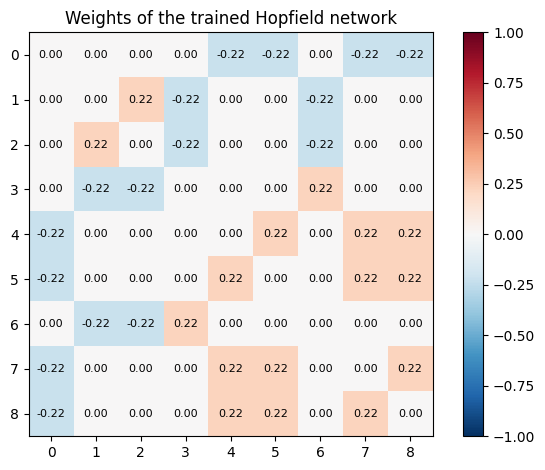

In [14]:
W = hopfield_net.weights.T

plt.figure()
plt.imshow(W, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Weights of the trained Hopfield network')

# Add numbers on top of each cell
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        plt.text(
            j, i, 
            f"{W[i, j]:.2f}",       # format (2 decimals)
            ha='center',
            va='center',
            color='black',
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [15]:
pattern_C = np.array([[1, 1, 1],
                      [-1, -1, -1],
                        [1, -1, -1]])

In [16]:
pattern_C.ravel(order='C')

array([ 1,  1,  1, -1, -1, -1,  1, -1, -1])

In [17]:
# Use the recall function to see if the network can recall pattern C
recalled_pattern_C = hopfield_net.recall(pattern_C, steps=1, synchronous=True)

In [18]:
recalled_pattern_C

array([[ 1.,  1.,  1.],
       [-1., -1., -1.],
       [-1., -1., -1.]])

In [19]:
# Test distance (norm) between original and recalled pattern
distance = np.linalg.norm(pattern_C.ravel(order='C') - recalled_pattern_C.ravel(order='C'))

print(f"Distance between original and recalled pattern C: {distance:.2f}")

Distance between original and recalled pattern C: 2.00


In [20]:
# Compute the energy of the original and recalled patterns
energy_A = hopfield_net.energy(pattern_A)
energy_B = hopfield_net.energy(pattern_B)
energy_C = hopfield_net.energy(pattern_C)

In [21]:
print(f"Energy of pattern A: {energy_A:.2f}")
print(f"Energy of pattern B: {energy_B:.2f}")
print(f"Energy of pattern C: {energy_C:.2f}")

Energy of pattern A: -3.56
Energy of pattern B: -3.56
Energy of pattern C: -2.22
